# Introduction to Matplotlib for Graduate Students

**Matplotlib** is Python's foundational plotting library. Nearly every other Python plotting
tool (pandas `.plot()`, seaborn, etc.) is built on top of it, so it's worth knowing the basics
directly.

This notebook covers:
1. Your first plot
2. The Figure/Axes model
3. Common plot types (line, scatter, bar, histogram)
4. Customizing a plot (labels, legend, colors, style)
5. Multiple subplots
6. Saving a figure
7. In-class example: plotting experimental data

---

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print(f"Matplotlib version: {matplotlib.__version__}")

Matplotlib version: 3.8.4


---

## Part 1: Your First Plot

The simplest way to plot is `plt.plot(x, y)` followed by `plt.show()`.

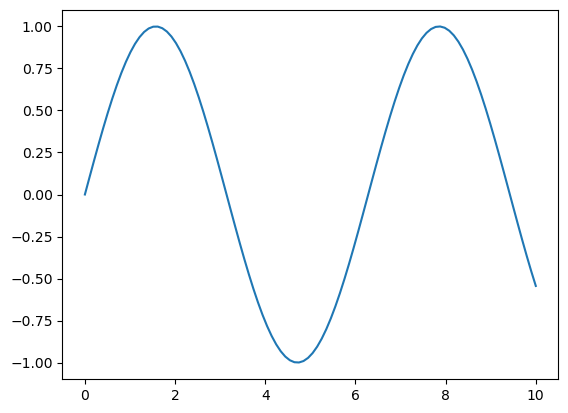

In [2]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.show()

That's it — `plt.plot()` draws a line through your points, and `plt.show()` displays it. In a Jupyter notebook, `plt.show()` is often optional (the figure displays automatically), but it's good practice to include it.

---

## Part 2: The Figure and Axes

Every matplotlib plot has two main objects:
- **Figure** — the whole window/canvas
- **Axes** — a single plot within the figure (a figure can contain multiple axes/subplots)

Using `plt.subplots()` to create both explicitly is the recommended, more controllable way to
plot (rather than relying on the implicit `plt.plot()` shortcut above).

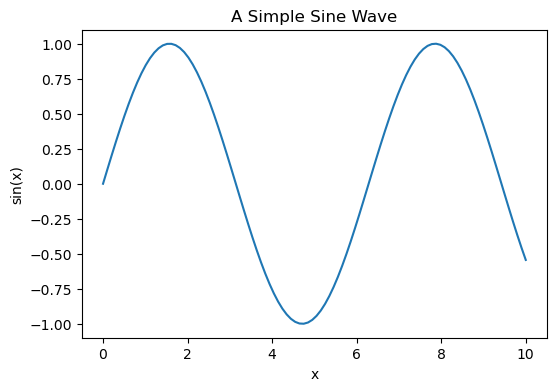

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, y)
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_title("A Simple Sine Wave")

plt.show()

---

## Part 3: Common Plot Types

### 3.1 Line Plot

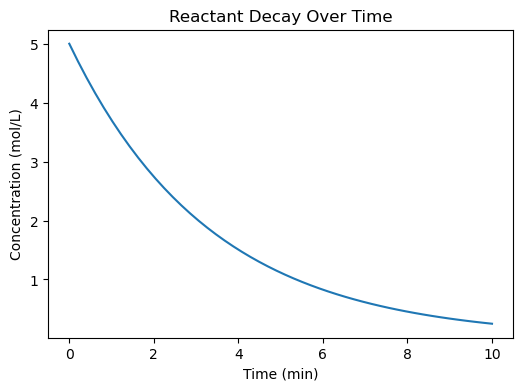

In [4]:
time = np.linspace(0, 10, 50)
concentration = 5 * np.exp(-0.3 * time)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time, concentration)
ax.set_xlabel("Time (min)")
ax.set_ylabel("Concentration (mol/L)")
ax.set_title("Reactant Decay Over Time")
plt.show()

### 3.2 Scatter Plot

Useful for showing individual data points, e.g., experimental measurements.

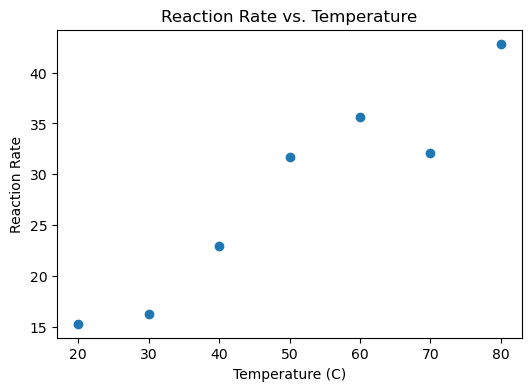

In [5]:
np.random.seed(0)
temperature = np.array([20, 30, 40, 50, 60, 70, 80])
reaction_rate = 0.5 * temperature + np.random.normal(0, 3, size=temperature.size)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(temperature, reaction_rate)
ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Reaction Rate")
ax.set_title("Reaction Rate vs. Temperature")
plt.show()

### 3.3 Bar Plot

Good for comparing categories.

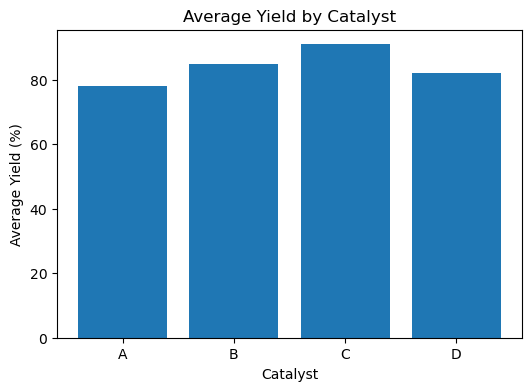

In [6]:
catalysts = ["A", "B", "C", "D"]
avg_yield = [78, 85, 91, 82]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(catalysts, avg_yield)
ax.set_xlabel("Catalyst")
ax.set_ylabel("Average Yield (%)")
ax.set_title("Average Yield by Catalyst")
plt.show()

### 3.4 Histogram

Shows the distribution of a set of values.

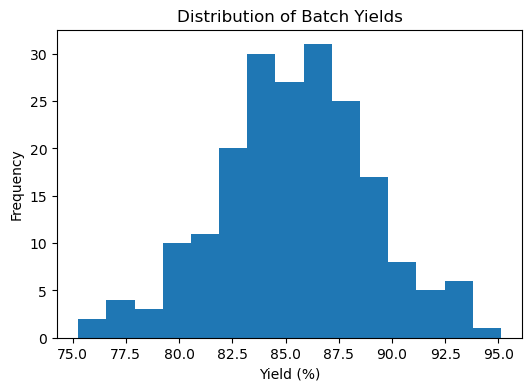

In [7]:
np.random.seed(1)
yields = np.random.normal(loc=85, scale=4, size=200)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(yields, bins=15)
ax.set_xlabel("Yield (%)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Batch Yields")
plt.show()

---

## Part 4: Customizing a Plot

### 4.1 Labels, Title, and Legend

Use the `label=` argument together with `ax.legend()` when plotting more than one series.

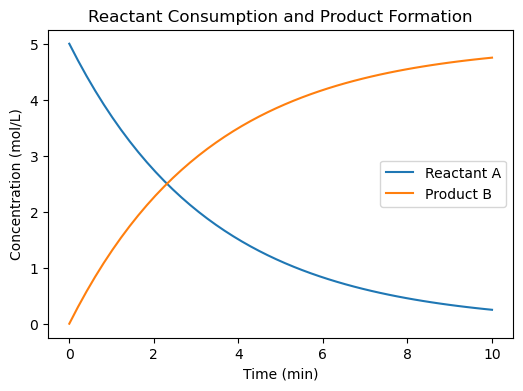

In [8]:
time = np.linspace(0, 10, 50)
CA = 5 * np.exp(-0.3 * time)
CB = 5 * (1 - np.exp(-0.3 * time))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time, CA, label="Reactant A")
ax.plot(time, CB, label="Product B")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Concentration (mol/L)")
ax.set_title("Reactant Consumption and Product Formation")
ax.legend()
plt.show()

### 4.2 Colors, Line Styles, and Markers

A short format string `'color-marker-linestyle'` is a quick way to control appearance, e.g. `'r--o'` = red, dashed, circle markers.

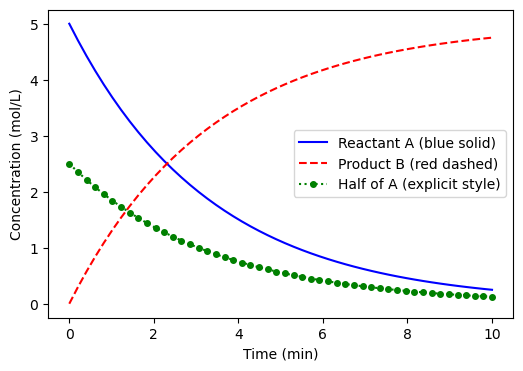

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(time, CA, 'b-', label="Reactant A (blue solid)")
ax.plot(time, CB, 'r--', label="Product B (red dashed)")

# You can also be explicit instead of using a format string:
ax.plot(time, CA * 0.5, color="green", linestyle=":", marker="o", markersize=4,
         label="Half of A (explicit style)")

ax.set_xlabel("Time (min)")
ax.set_ylabel("Concentration (mol/L)")
ax.legend()
plt.show()

### 4.3 Axis Limits and Grid

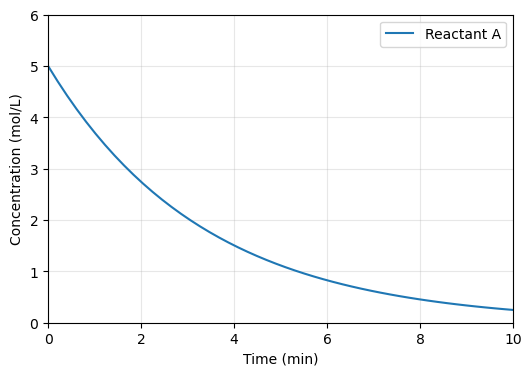

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time, CA, label="Reactant A")
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3)
ax.set_xlabel("Time (min)")
ax.set_ylabel("Concentration (mol/L)")
ax.legend()
plt.show()

---

## Part 5: Multiple Subplots

`plt.subplots(nrows, ncols)` creates a grid of axes at once. It returns an array of `Axes`
objects you can index into.

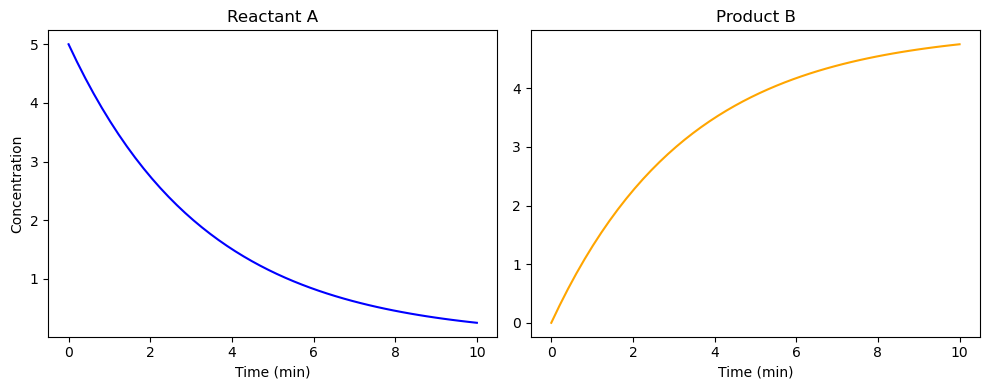

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(time, CA, color="blue")
axes[0].set_title("Reactant A")
axes[0].set_xlabel("Time (min)")
axes[0].set_ylabel("Concentration")

axes[1].plot(time, CB, color="orange")
axes[1].set_title("Product B")
axes[1].set_xlabel("Time (min)")

plt.tight_layout()  # prevents labels/titles from overlapping
plt.show()

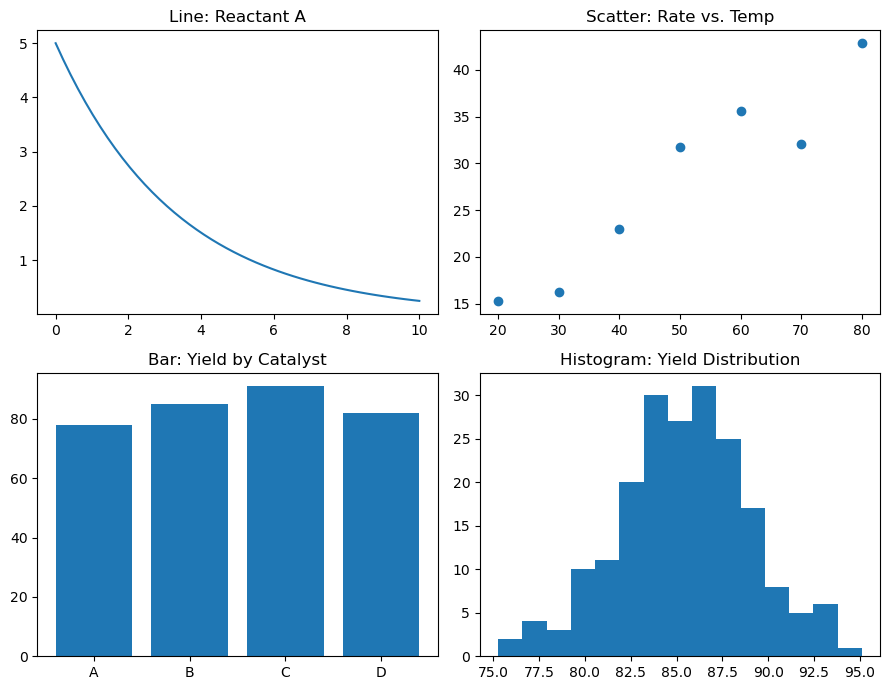

In [12]:
# A 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

axes[0, 0].plot(time, CA)
axes[0, 0].set_title("Line: Reactant A")

axes[0, 1].scatter(temperature, reaction_rate)
axes[0, 1].set_title("Scatter: Rate vs. Temp")

axes[1, 0].bar(catalysts, avg_yield)
axes[1, 0].set_title("Bar: Yield by Catalyst")

axes[1, 1].hist(yields, bins=15)
axes[1, 1].set_title("Histogram: Yield Distribution")

plt.tight_layout()
plt.show()

---

## Part 6: Saving a Figure

Use `fig.savefig()` (or `plt.savefig()`) *before* `plt.show()`. Common formats: `.png` for
raster images, `.pdf` or `.svg` for vector graphics (better for papers/posters).

Saved reactant_decay.png


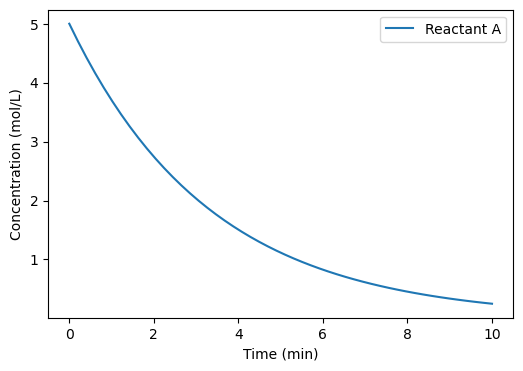

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time, CA, label="Reactant A")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Concentration (mol/L)")
ax.legend()

fig.savefig("reactant_decay.png", dpi=300, bbox_inches="tight")
print("Saved reactant_decay.png")

plt.show()

---

## Part 7: In-Class Example — Plotting Experimental Data

**Scenario:** You measured reactant concentration over time in triplicate (three repeated runs)
and want a single plot showing the average trend with error bars.

**Tasks:**
1. Compute the mean and standard deviation across the three runs at each time point
2. Plot the mean as a line with error bars showing +/- 1 standard deviation
3. Add proper labels, a title, and a legend
4. Save the figure

In [16]:
# --- Simulated triplicate experimental data ---
np.random.seed(5)
time_exp = np.array([0, 1, 2, 3, 4, 5, 6, 8, 10])
true_C = 5 * np.exp(-0.3 * time_exp)

run1 = true_C + np.random.normal(0, 0.15, size=time_exp.size)
run2 = true_C + np.random.normal(0, 0.15, size=time_exp.size)
run3 = true_C + np.random.normal(0, 0.15, size=time_exp.size)

runs = np.vstack([run1, run2, run3])
mean_C = runs.mean(axis=0)
std_C = runs.std(axis=0, ddof=1)

print("Time:", time_exp)
print("Mean concentration:", np.round(mean_C, 2))
print("Std dev:", np.round(std_C, 2))

Time: [ 0  1  2  3  4  5  6  8 10]
Mean concentration: [4.93 3.66 2.81 1.96 1.5  1.09 0.8  0.52 0.35]
Std dev: [0.15 0.14 0.27 0.05 0.11 0.25 0.16 0.14 0.15]


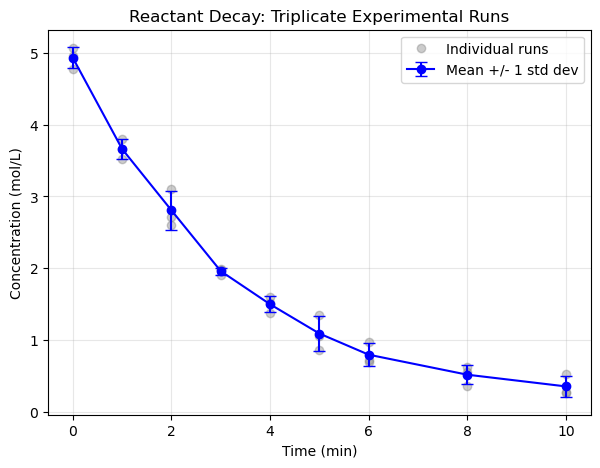

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

# Individual runs, lightly shown
for i, run in enumerate(runs, start=1):
    ax.plot(time_exp, run, 'o', color="gray", alpha=0.4,
             label="Individual runs" if i == 1 else None)

# Mean with error bars
ax.errorbar(time_exp, mean_C, yerr=std_C, fmt='-o', color="blue",
             capsize=4, label="Mean +/- 1 std dev")

ax.set_xlabel("Time (min)")
ax.set_ylabel("Concentration (mol/L)")
ax.set_title("Reactant Decay: Triplicate Experimental Runs")
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig("triplicate_decay.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Summary: Key Matplotlib Concepts Covered

| Concept | Functions | Description |
|---|---|---|
| **Basic plotting** | `plt.plot()`, `plt.show()` | Quick, implicit plotting |
| **Figure/Axes** | `plt.subplots()` | The recommended, explicit way to build a plot |
| **Plot types** | `.plot()`, `.scatter()`, `.bar()`, `.hist()`, `.errorbar()` | Line, scatter, bar, histogram, error bars |
| **Customization** | `.set_xlabel()`, `.set_ylabel()`, `.set_title()`, `.legend()`, `.grid()` | Labeling and styling |
| **Style shortcuts** | format strings (`'r--o'`), `color=`, `linestyle=`, `marker=` | Controlling line/marker appearance |
| **Multiple plots** | `plt.subplots(nrows, ncols)`, `plt.tight_layout()` | Grids of subplots |
| **Saving** | `fig.savefig()` | Exporting to PNG/PDF/SVG |

---

## Exercises for Practice

1. Plot `cos(x)` alongside `sin(x)` on the same axes with a legend.
2. Create a bar plot comparing average yield across 5 catalysts, with the bars colored
   differently based on whether the yield is above or below 85%.
3. Make a 1x3 subplot grid showing a line plot, scatter plot, and histogram side by side.
4. Recreate the triplicate error-bar plot (Part 7) but with 5 repeated runs instead of 3.
5. Save one of your figures as both a `.png` and a `.pdf` and compare file sizes.

---

